In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
# Load dataset
sold = pd.read_csv("combined_sold_residential.csv", low_memory=False)

In [26]:
# Inspect dataset structure
print("Shape (rows, cols):", sold.shape)
print("\nColumns:")
print(sold.columns)
print("\nPreview:")
print(sold.head())
print("\nData types:")
print(sold.dtypes)

Shape (rows, cols): (397603, 84)

Columns:
Index(['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN',
       'BasementYN', 'PoolPrivateYN', 'OriginalListPrice', 'ListingKey',
       'ListAgentEmail', 'CloseDate', 'ClosePrice', 'ListAgentFirstName',
       'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress',
       'PropertyType', 'LivingArea', 'ListPrice', 'DaysOnMarket',
       'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName',
       'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName',
       'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName',
       'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea',
       'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount',
       'CountyOrParish', 'MlsStatus', 'ElementarySchool', 'AttachedGarageYN',
       'ParkingTotal', 'BuilderName', 'PropertySubType', 'LotSizeAcres',
       'SubdivisionName', 'BuyerOfficeAOR', 'YearBuilt', 'StreetNumberNumeric',
       'Lis

In [27]:
# Unique property types
property_types = sold['PropertyType'].unique()
print("\nProperty Types Found:")
print(property_types)


Property Types Found:
['Residential']


In [28]:
# Filter residential (sanity check)
sold = sold[sold['PropertyType'] == 'Residential']
print("\nShape after filtering:", sold.shape)


Shape after filtering: (397603, 84)


In [29]:
# Count missing values
missing_counts = sold.isnull().sum()

In [30]:
# Percent missing
missing_percent = (missing_counts / len(sold)) * 100

In [31]:
# Combine into one table
missing_df = pd.DataFrame({
    'MissingCount': missing_counts,
    'MissingPercent': missing_percent
})

In [32]:
print("\nMissing Value Summary:")
print(missing_df.sort_values(by = 'MissingPercent', ascending=False))


Missing Value Summary:
                              MissingCount  MissingPercent
CoveredSpaces                       397603           100.0
MiddleOrJuniorSchoolDistrict        397603           100.0
AboveGradeFinishedArea              397603           100.0
FireplacesTotal                     397603           100.0
TaxYear                             397603           100.0
...                                    ...             ...
DaysOnMarket                             0             0.0
ListOfficeName                           0             0.0
ListingId                                0             0.0
ListingKeyNumeric                        0             0.0
ListPrice                                0             0.0

[84 rows x 2 columns]


In [33]:
# Flag columns with >90% missing
high_missing = missing_df[missing_df['MissingPercent'] > 90]
print("\nColumns with >90% missing:")
print(high_missing)


Columns with >90% missing:
                              MissingCount  MissingPercent
WaterfrontYN                        397355       99.937626
BasementYN                          389826       98.044029
FireplacesTotal                     397603      100.000000
AboveGradeFinishedArea              397603      100.000000
TaxAnnualAmount                     397603      100.000000
BuilderName                         378056       95.083790
TaxYear                             397603      100.000000
BuildingAreaTotal                   369810       93.009862
ElementarySchoolDistrict            397603      100.000000
CoBuyerAgentFirstName               361576       90.938952
BelowGradeFinishedArea              395313       99.424049
BusinessType                        397603      100.000000
CoveredSpaces                       397603      100.000000
LotSizeDimensions                   378282       95.140630
MiddleOrJuniorSchoolDistrict        397603      100.000000
OriginatingSystemName       

In [34]:
# Drop high-missing columns (except core ones)
core_cols = ['ClosePrice', 'ListPrice', 'LivingArea', 'DaysOnMarket']
cols_to_drop = [col for col in high_missing.index if col not in core_cols]
sold = sold.drop(columns=cols_to_drop)
print("\nDropped columns:", cols_to_drop)


Dropped columns: ['WaterfrontYN', 'BasementYN', 'FireplacesTotal', 'AboveGradeFinishedArea', 'TaxAnnualAmount', 'BuilderName', 'TaxYear', 'BuildingAreaTotal', 'ElementarySchoolDistrict', 'CoBuyerAgentFirstName', 'BelowGradeFinishedArea', 'BusinessType', 'CoveredSpaces', 'LotSizeDimensions', 'MiddleOrJuniorSchoolDistrict', 'OriginatingSystemName', 'OriginatingSystemSubName']


In [35]:
# Numeric distribution summary
numeric_cols = [ 'ClosePrice', 'ListPrice', 'OriginalListPrice', 'LivingArea', 'LotSizeAcres', 'BedroomsTotal', 'BathroomsTotalInteger', 'DaysOnMarket', 'YearBuilt' ]
numeric_cols = [col for col in numeric_cols if col in sold.columns]
summary = sold[numeric_cols].describe(percentiles = [0.25, 0.5, 0.75, 0.9, 0.95])
print("\nNumeric Summary:")
print(summary)


Numeric Summary:
         ClosePrice     ListPrice  OriginalListPrice    LivingArea  \
count  3.976010e+05  3.976030e+05       3.968820e+05  3.973740e+05   
mean   1.185616e+06  1.138630e+06       1.224737e+06  1.904351e+03   
std    5.922380e+06  1.353707e+06       6.779804e+06  2.701781e+04   
min    0.000000e+00  5.250000e+02       0.000000e+00  0.000000e+00   
25%    5.750000e+05  5.750000e+05       5.850000e+05  1.247000e+03   
50%    8.200000e+05  8.150000e+05       8.250000e+05  1.641000e+03   
75%    1.300000e+06  1.295000e+06       1.299000e+06  2.217000e+03   
90%    2.058600e+06  1.999000e+06       2.050000e+06  2.975000e+03   
95%    2.850000e+06  2.850000e+06       2.899000e+06  3.558000e+03   
max    9.895000e+08  1.375000e+08       1.390000e+09  1.702132e+07   

       LotSizeAcres  BedroomsTotal  BathroomsTotalInteger   DaysOnMarket  \
count  3.662390e+05  397592.000000          397534.000000  397603.000000   
mean   6.855894e+01       3.200200               2.533185  

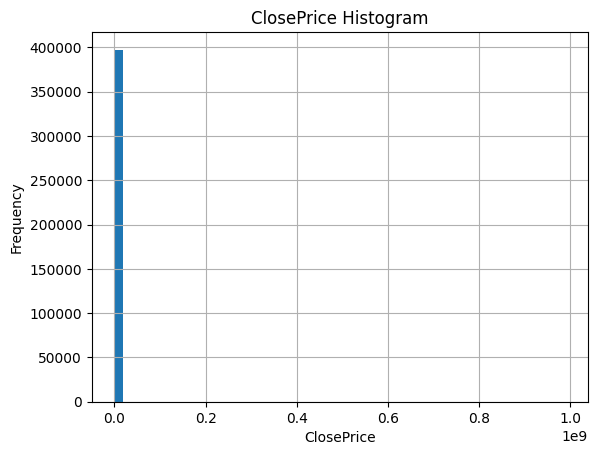

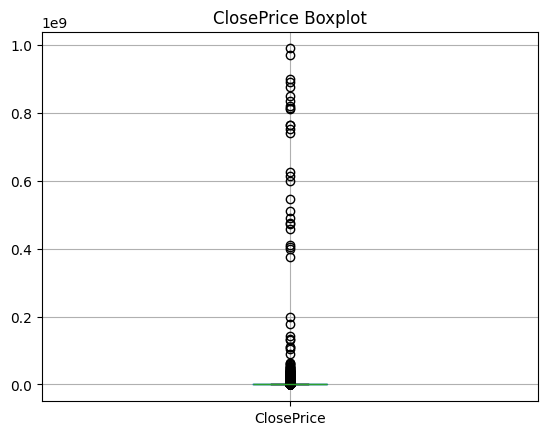

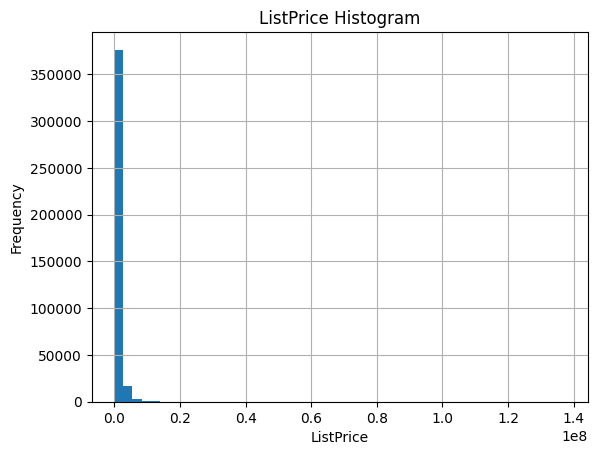

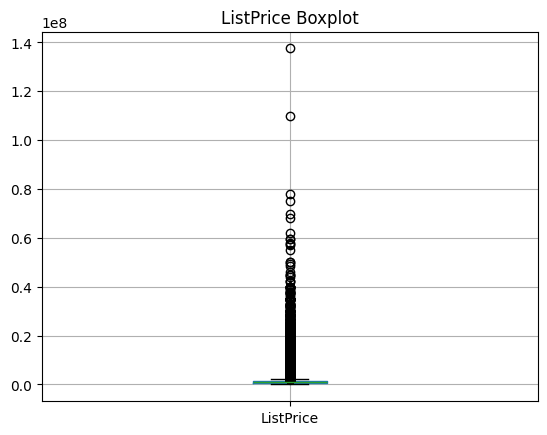

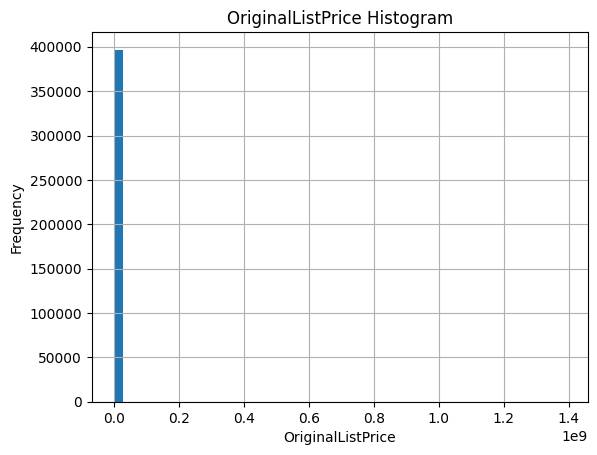

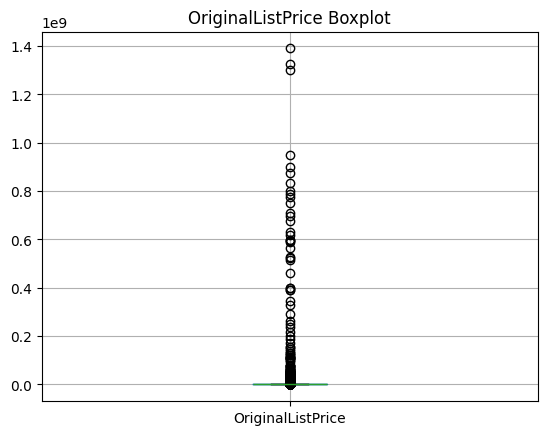

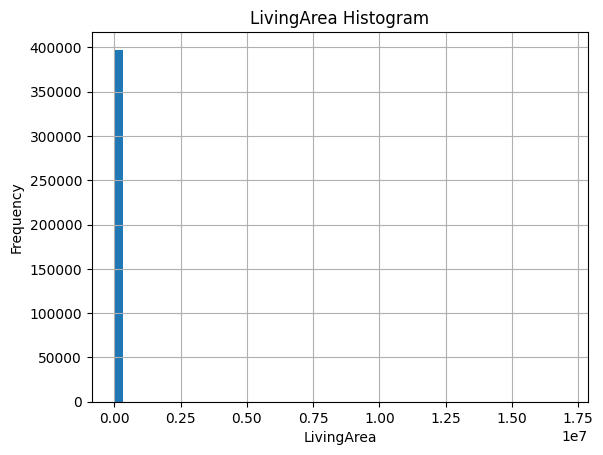

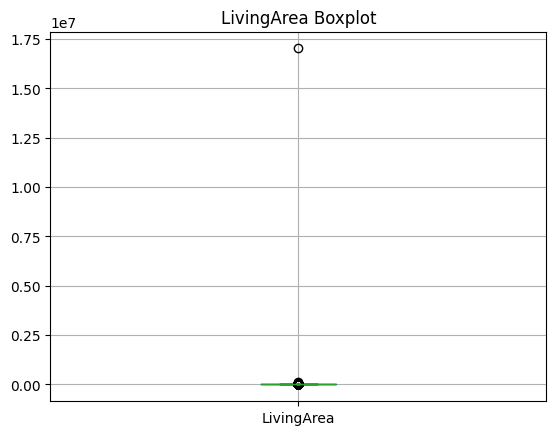

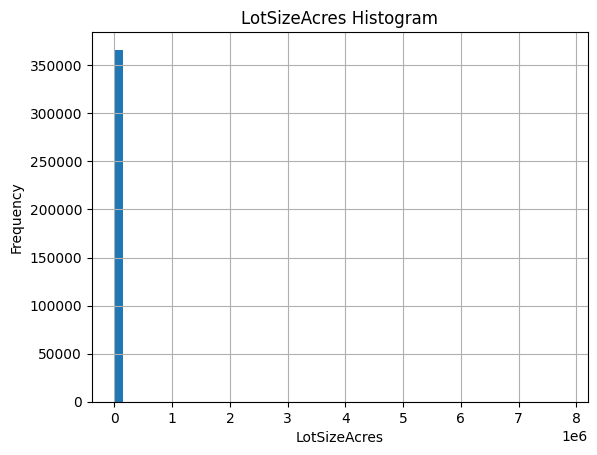

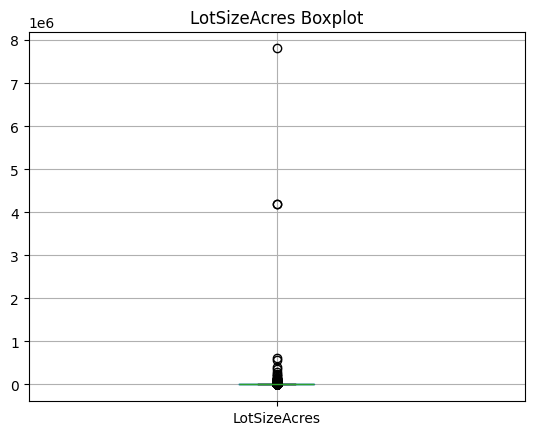

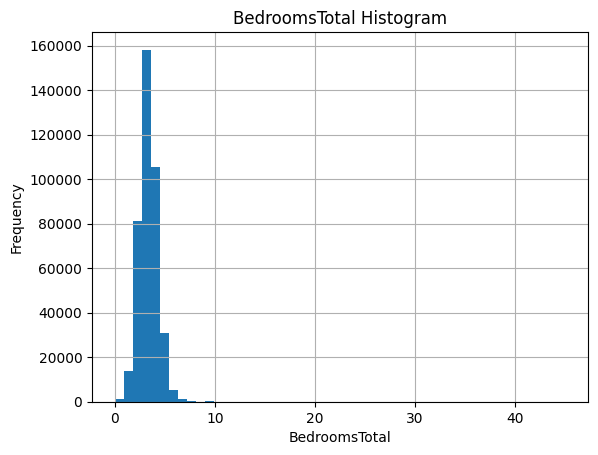

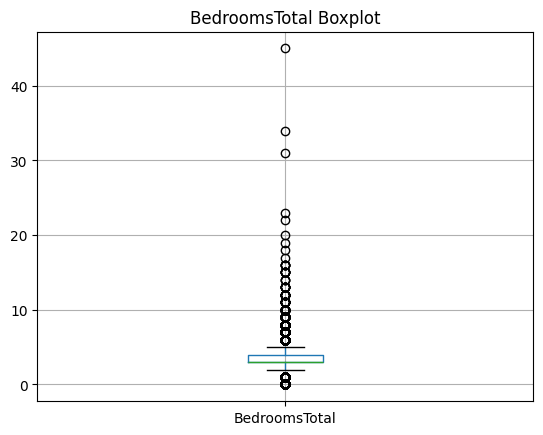

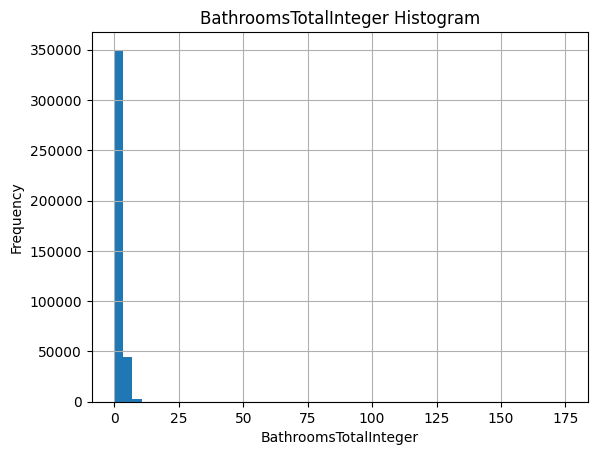

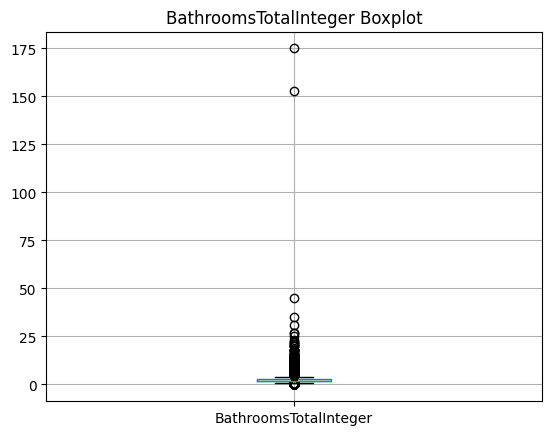

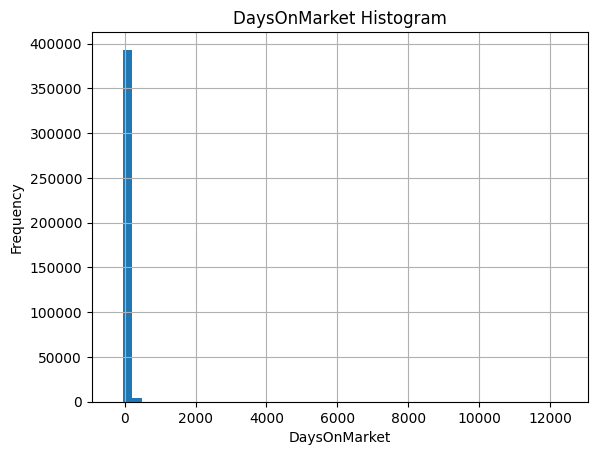

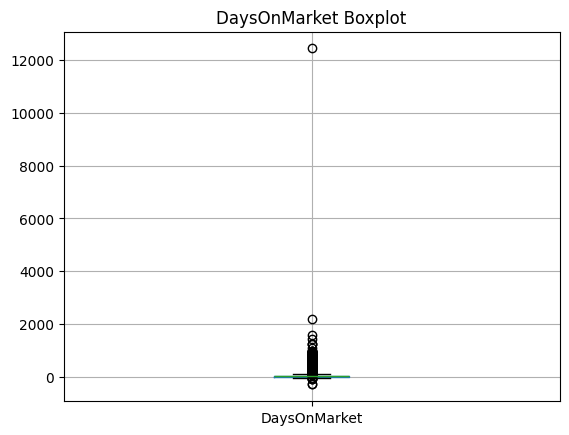

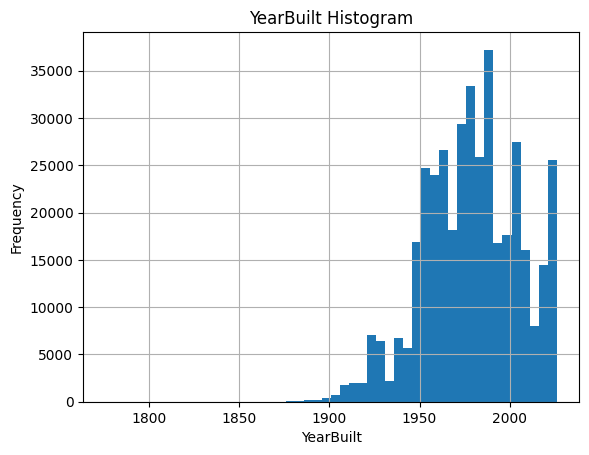

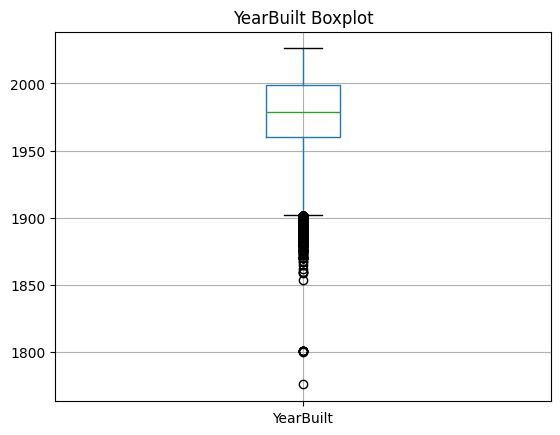

In [36]:
# Histograms and Boxplots
for col in numeric_cols:
    plt.figure()
    sold[col].hist(bins = 50)
    plt.title(f"{col} Histogram")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

    plt.figure()
    sold.boxplot(column = col)
    plt.title(f"{col} Boxplot")
    plt.show()

In [37]:
# Negative DaysOnMarket
invalid_dom = sold[sold['DaysOnMarket'] < 0]
print("Negative DaysOnMarket records:", len(invalid_dom))

Negative DaysOnMarket records: 46


In [38]:
# Zero prices
zero_prices = sold[sold['ClosePrice'] == 0]
print("Zero price records:", len(zero_prices))

Zero price records: 1


In [39]:
# Flag outliers
print("Max ClosePrice:", sold['ClosePrice'].max())
print("Max LivingArea:", sold['LivingArea'].max())

Max ClosePrice: 989500000.0
Max LivingArea: 17021321.0


In [40]:
# Basic data cleaning
if 'DaysOnMarket' in sold.columns:
    sold = sold[sold['DaysOnMarket'] >= 0]
if 'ClosePrice' in sold.columns:
    sold = sold[sold['ClosePrice'] > 0]
if 'ListPrice' in sold.columns:
    sold = sold[sold['ListPrice'] > 0]
print("After cleaning shape", sold.shape)

After cleaning shape (397554, 67)


In [41]:
# Residential vs others (already filtered?)
original = pd.read_csv("combined_sold_residential.csv", low_memory=False)
type_counts = original['PropertyType'].value_counts(normalize=True) * 100
print("\nProperty Type Share (%):")
print(type_counts)


Property Type Share (%):
PropertyType
Residential    100.0
Name: proportion, dtype: float64


In [42]:
# Median and Average close price
print("Median Close Price:", sold['ClosePrice'].median())
print("Average Close Price:", sold['ClosePrice'].mean())

Median Close Price: 820000.0
Average Close Price: 1185673.1656006726


In [43]:
# Days on market distribution
print(sold['DaysOnMarket'].describe())

count    397554.000000
mean         37.344132
std          53.533716
min           0.000000
25%           8.000000
50%          19.000000
75%          48.000000
max       12430.000000
Name: DaysOnMarket, dtype: float64


In [44]:
# Above vs below list price
percent_above = (sold['ClosePrice'] > sold['ListPrice']).mean() * 100
percent_below = (sold['ClosePrice'] < sold['ListPrice']).mean() * 100
print("Percent sold above list:", percent_above)
print("Percent sold below list:", percent_below)

Percent sold above list: 40.109771251201096
Percent sold below list: 42.546169828501284


In [45]:
# Date consistency check
sold['CloseDate'] = pd.to_datetime(sold['CloseDate'], errors = 'coerce')
sold['ListingContractDate'] = pd.to_datetime(sold['ListingContractDate'], errors = 'coerce')
invalid_dates = sold[sold['CloseDate'] < sold['ListingContractDate']]
print("Invalid date records:", len(invalid_dates))

Invalid date records: 58


In [46]:
# Highest median prices by county
county_prices = sold.groupby('CountyOrParish')['ClosePrice'].median().sort_values(ascending=False)
print("\nMedian Price by County:")
print(county_prices.head(10))


Median Price by County:
CountyOrParish
Del Norte        2485000.0
Other County     2462500.0
San Mateo        1700000.0
Santa Clara      1600000.0
Santa Cruz       1200000.0
San Francisco    1180000.0
Orange           1175000.0
Marin            1170000.0
Alameda          1135000.0
Alpine           1100000.0
Name: ClosePrice, dtype: float64
